# Modelling step

In this notebook, we will use the preprocessed dataset produced previously to train and evaluate two different regression models.

Both of these model will predict the target `wage_gap` (the proportional female-male wage gap) based on the values of the six prepared input features:
* `education_gap`
* `employment_gap`
* `native_gap`
* `immigrant_gap`
* `gdp_pc`
* `part_time_gap`

The first model is a Decision Tree. The second is a Neural Network with two hidden layers, following a pyramid structure design.

Note that the input features for the Neural Network model have been scaled according to a MinMax technique, given that, unlike the Decision Tree, this type of model is sensitive to the scale of the input data.

The same 70-30 train-test split datasets were used to train and evaluate both models, in order to ensure that the results are comparable.

## Imports and definitions

In [1]:
import copy
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from lime.lime_tabular import LimeTabularExplainer
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree


In [2]:
target = "wage_gap"

features = [
    "education_gap",
    "employment_gap",
    "native_gap",
    "immigrant_gap",
    "gdp_pc",
    "part_time_gap"
]

train_size = 0.7

In [3]:
# Set all random seeds for reproducibility

random_seed_value = 48

torch.manual_seed(random_seed_value)
np.random.seed(random_seed_value)

## Creation of the train and test datasets

In [4]:
df = pd.read_csv("../data/FINAL_DATASET.csv")

display(df.dtypes)
display(df.head(2))

country            object
year                int64
wage_gap          float64
education_gap     float64
employment_gap    float64
native_gap        float64
immigrant_gap     float64
gdp_pc            float64
part_time_gap     float64
dtype: object

,country,year,wage_gap,education_gap,employment_gap,native_gap,immigrant_gap,gdp_pc,part_time_gap
0,Australia,2010,20.381232,-6.382107,16.347199,11.279961,17.517487,122.776402,-43.772
1,Australia,2011,19.458304,-7.470135,16.211098,10.694275,17.213684,123.987878,-44.942


In [5]:
df.describe()

,year,wage_gap,education_gap,employment_gap,native_gap,immigrant_gap,gdp_pc,part_time_gap
count,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000,518.000000
mean,2016.500000,16.186115,-5.962259,12.929759,10.280404,15.599538,103.742656,-41.136133
std,4.035026,6.487558,6.693212,8.393347,6.884498,6.062943,41.927910,12.876995
min,2010.000000,-0.297029,-22.699179,-1.606552,0.028450,3.563530,33.441652,-70.858000
25%,2013.000000,11.954341,-10.503915,7.584916,5.806147,12.000000,77.121355,-51.396250
50%,2016.500000,16.003406,-6.063821,10.766654,8.014072,15.398693,97.860996,-40.520000
75%,2020.000000,19.944810,-1.833586,15.455013,12.939880,18.050714,126.914642,-30.754250
max,2023.000000,37.043847,12.610080,39.104080,36.464100,38.286648,287.736306,-14.630000


In [6]:
X = df[features].values
y = df[target].values

print(X.shape, y.shape)

(518, 6) (518,)


In [7]:
# Split data to be used for model training and for testing

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, shuffle=True)

print(
    f"Row count in training set: {X_train.shape[0]}",
    f"Row count in test set:     {X_test.shape[0]}",
    f"Proportion:                {round(X_train.shape[0] / (X_train.shape[0] + X_test.shape[0]), 2)}",
    sep="\n",
)

Row count in training set: 362
Row count in test set:     156
Proportion:                0.7


In [8]:
# Scale input features for the Neural Network

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(
    f"Input feature minimum values: scaled from {np.min(X_train)} to {np.min(X_train_scaled)}",
    f"Input feature maximum values: scaled from {np.max(X_train)} to {np.max(X_train_scaled)}",
    sep="\n",
)

Input feature minimum values: scaled from -70.858 to 0.0
Input feature maximum values: scaled from 287.736306 to 1.0


## Train Decision Tree

In [9]:
# Random search to determine best model hyperparameters

param_search_space = {
    "max_depth": list(range(2, 10)),
    "min_samples_leaf": list(range(5, 20)),
}

model = DecisionTreeRegressor()

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_search_space,
    n_iter=100,
    scoring="neg_root_mean_squared_error",
    cv=3,
)

random_search.fit(X_train, y_train)

# RandomizedSearchCV returns the negative of the RMSE because it needs to maximize it
best_score = abs(random_search.best_score_)
best_params = random_search.best_params_

print(
    f"Best hyperparameters: {random_search.best_params_}",
    f"Best RMSE score:      {best_score}",
    sep="\n",
)

Best hyperparameters: {'min_samples_leaf': 6, 'max_depth': 9}
Best RMSE score:      4.108192519342524


In [10]:
# Train and evaluate model with the best hyperparameters found

model = DecisionTreeRegressor(**best_params)
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
rmse_train = mean_squared_error(y_train, y_pred_train) ** 0.5

y_pred_test = model.predict(X_test)
rmse_test = mean_squared_error(y_test, y_pred_test) ** 0.5

print(
    f"RMSE on train dataset: {rmse_train:.4f}",
    f"RMSE on test dataset: {rmse_test:.4f}",
    sep="\n",
)

RMSE on train dataset: 2.6460
RMSE on test dataset: 5.0598


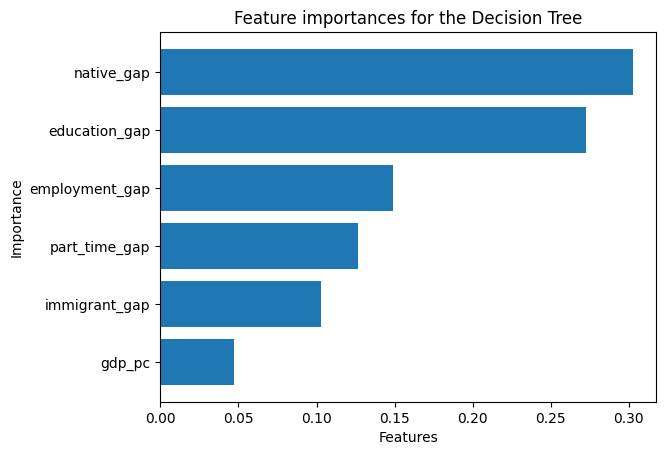

In [11]:
# Display feature importances

importances = model.feature_importances_
indices = np.argsort(importances)
feature_names = [features[i] for i in indices]

plt.title("Feature importances for the Decision Tree")
plt.barh(feature_names, importances[indices])
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [12]:
# Train and evaluate model with the best hyperparameters found and removing GDP from input features

gpd_col = features.index("gdp_pc")
new_X_train = np.delete(X_train, gpd_col, axis=1)
new_X_test = np.delete(X_test, gpd_col, axis=1)

model = DecisionTreeRegressor(**best_params)
model.fit(new_X_train, y_train)

y_pred_train = model.predict(new_X_train)
rmse_train = mean_squared_error(y_train, y_pred_train) ** 0.5

y_pred_test = model.predict(new_X_test)
rmse_test = mean_squared_error(y_test, y_pred_test) ** 0.5

print(
    f"RMSE on train dataset: {rmse_train:.4f}",
    f"RMSE on test dataset: {rmse_test:.4f}",
    sep="\n",
)

RMSE on train dataset: 2.6868
RMSE on test dataset: 5.1905


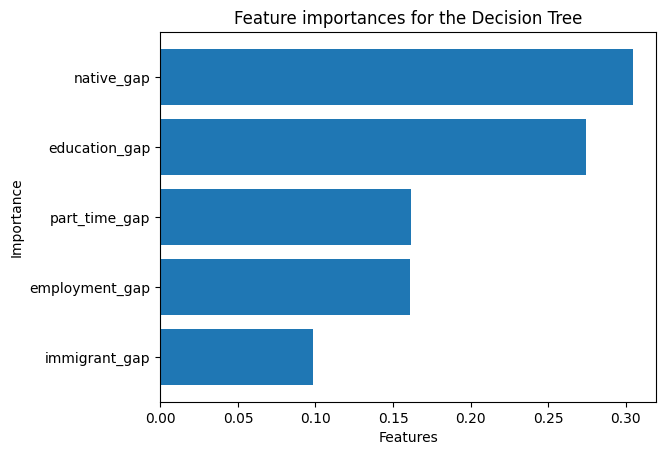

In [13]:
# Display feature importances

importances = model.feature_importances_
indices = np.argsort(importances)
feature_names = [[f for f in features if f != "gdp_pc"][i] for i in indices]

plt.title("Feature importances for the Decision Tree")
plt.barh(feature_names, importances[indices])
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

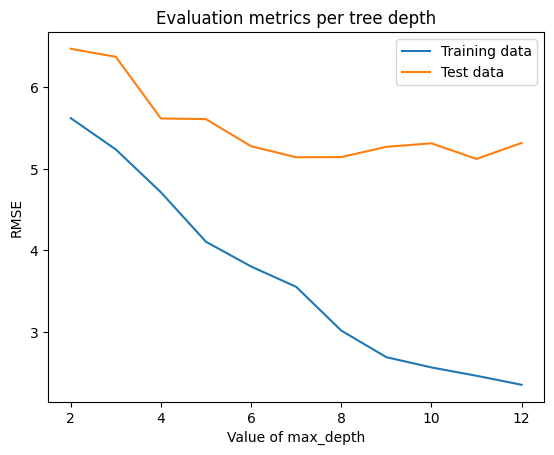

In [14]:
errors_per_tree_depth = {}
model_candidates = {}

for d in [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]:
    candidate = DecisionTreeRegressor(min_samples_leaf=6, max_depth=d)
    candidate.fit(new_X_train, y_train)

    y_pred_train = candidate.predict(new_X_train)
    y_pred_test = candidate.predict(new_X_test)

    model_candidates[d] = candidate
    errors_per_tree_depth[d] = (
        mean_squared_error(y_train, y_pred_train) ** 0.5,
        mean_squared_error(y_test, y_pred_test) ** 0.5,
    )

plot_x = sorted(list(errors_per_tree_depth.keys()))
plot_y_train = [errors_per_tree_depth[x][0] for x in plot_x]
plot_y_test = [errors_per_tree_depth[x][1] for x in plot_x]

plt.plot(plot_x, plot_y_train, label="Training data")
plt.plot(plot_x, plot_y_test, label="Test data")
plt.legend()
plt.title("Evaluation metrics per tree depth")
plt.xlabel("Value of max_depth")
plt.ylabel("RMSE")
plt.show()

In [15]:
# Train and evaluate model with max_depth = 6

model = DecisionTreeRegressor(min_samples_leaf=6, max_depth=6)
model.fit(new_X_train, y_train)

y_pred_train = model.predict(new_X_train)
rmse_train = mean_squared_error(y_train, y_pred_train) ** 0.5

y_pred_test = model.predict(new_X_test)
rmse_test = mean_squared_error(y_test, y_pred_test) ** 0.5

print(
    f"RMSE on train dataset: {rmse_train:.4f}",
    f"RMSE on test dataset: {rmse_test:.4f}",
    sep="\n",
)

RMSE on train dataset: 3.7997
RMSE on test dataset: 5.2760


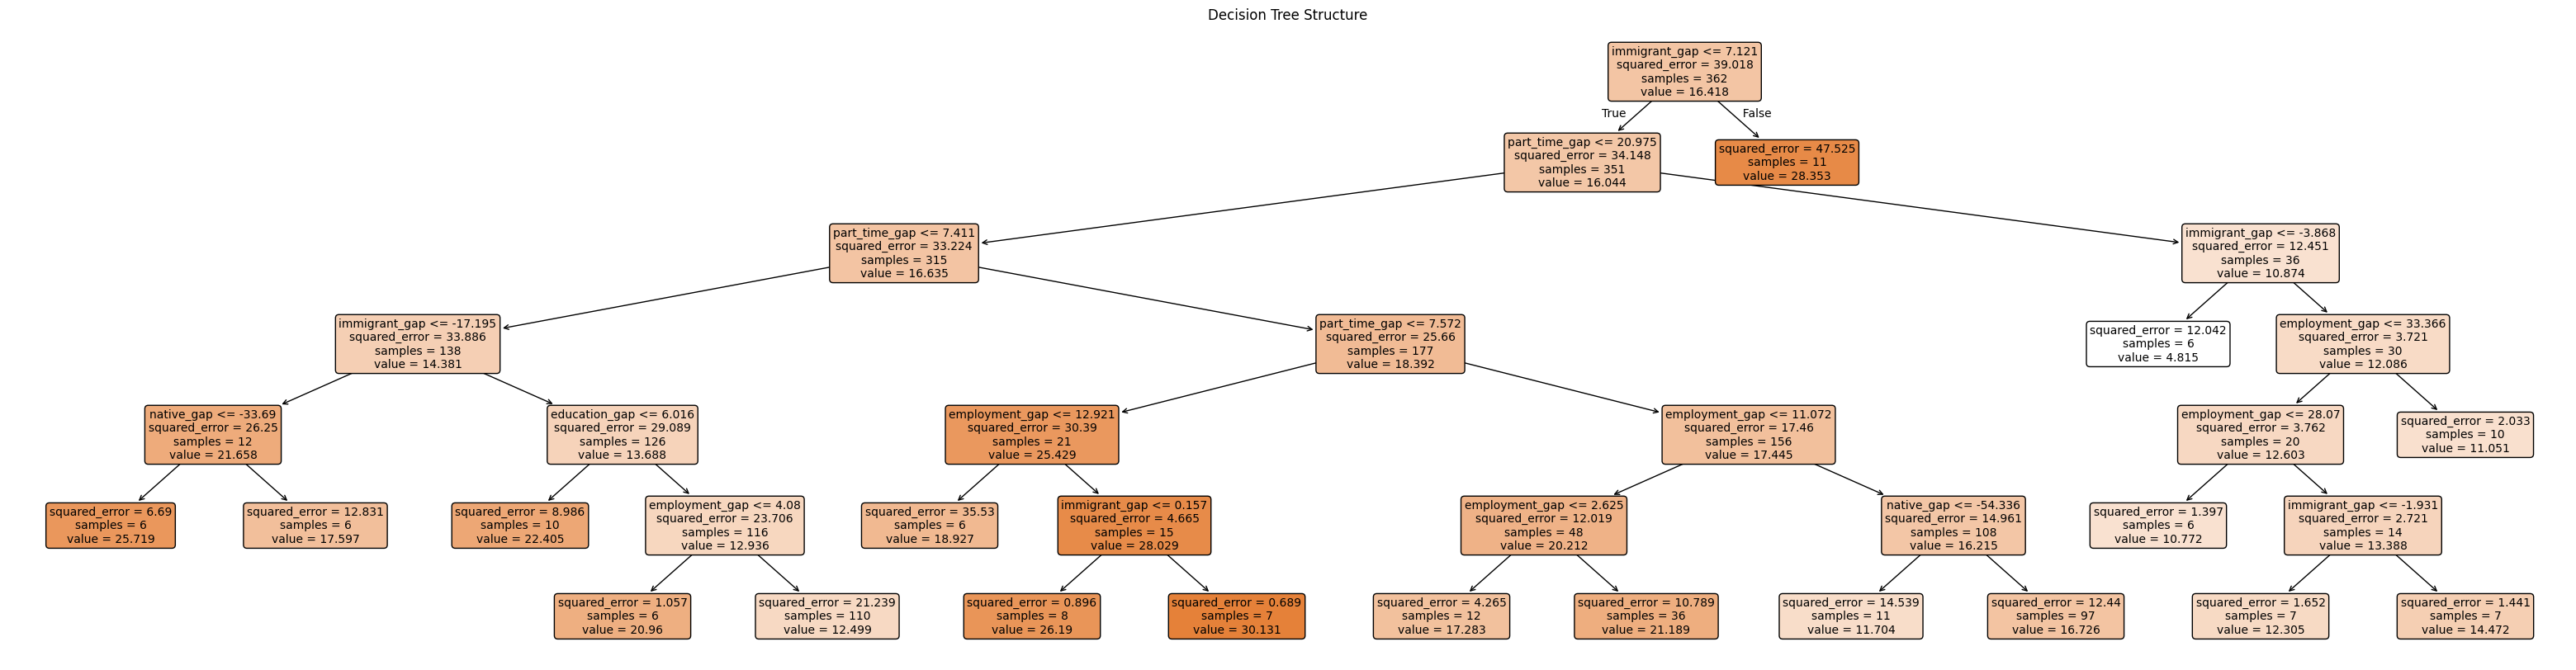

In [16]:
# Display the Decision Tree

plt.figure(figsize=(40, 10))
plot_tree(
    model,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title("Decision Tree Structure")
plt.show()

In [17]:
# Save model

with open("models/best_decision_tree.pkl", "wb") as fp:
    pickle.dump(model, fp)

### Create a LIME Explainer for the Decision Tree

In [18]:
explainer = LimeTabularExplainer(
    training_data=new_X_train,
    feature_names=feature_names,
    mode="regression",
)

True wage gap:   9.3446422795
Predicted value: 12.49854927950909
[('immigrant_gap', -11.5581805), ('employment_gap', 7.556789500000001), ('part_time_gap', 5.683052060000001), ('education_gap', 16.2462616), ('native_gap', -27.784)]
[('part_time_gap <= 5.86', -1.3613016701023473), ('7.49 < employment_gap <= 10.70', 1.2807987102310339), ('native_gap > -31.94', -0.26236807976706544), ('immigrant_gap <= -10.36', 0.10341061043156159), ('15.52 < education_gap <= 18.01', -0.002513041470651272)]


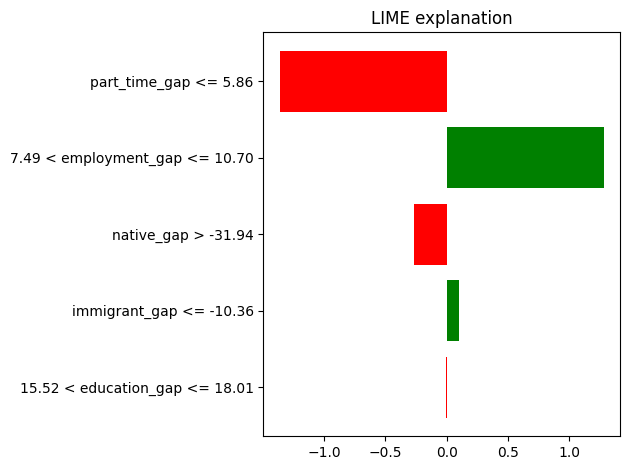

True wage gap:   11.78612838
Predicted value: 11.051016894099998
[('immigrant_gap', 2.093349), ('employment_gap', 37.76968299999999), ('part_time_gap', 34.87826919), ('education_gap', 32.135917660000004), ('native_gap', -19.53)]
[('part_time_gap > 12.86', -3.0514339336087266), ('immigrant_gap > -1.79', 2.0055226101987054), ('employment_gap > 15.68', -1.6447412124952758), ('education_gap > 18.01', -0.25049634366158097), ('native_gap > -31.94', 0.18676734279576135)]


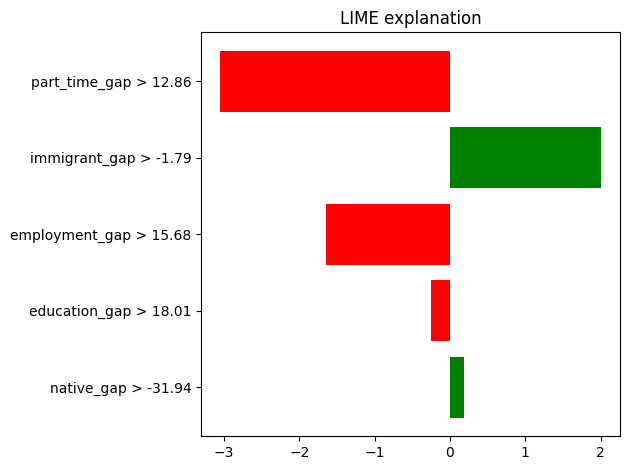

True wage gap:   17.08334338
Predicted value: 16.725969043314436
[('immigrant_gap', 0.3977140000000005), ('employment_gap', 25.144589000000003), ('part_time_gap', 20.487987520000004), ('education_gap', 28.20707321), ('native_gap', -34.774)]
[('part_time_gap > 12.86', -3.10237945638551), ('immigrant_gap > -1.79', 1.9566576062789243), ('employment_gap > 15.68', -1.7066025362047612), ('-40.73 < native_gap <= -31.94', 0.3785857439113087), ('education_gap > 18.01', -0.2638516615310161)]


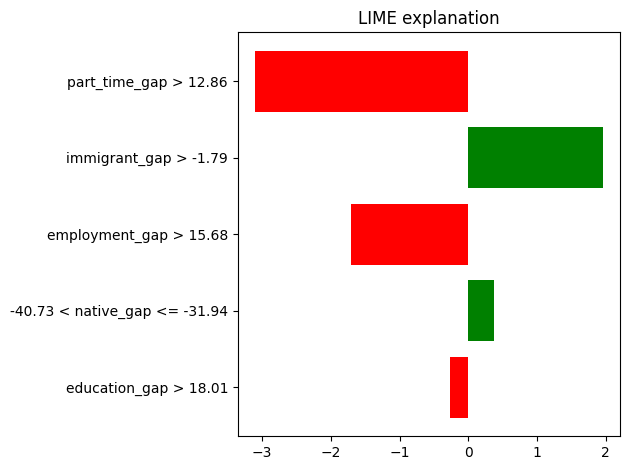

In [19]:
# Visualize some test data points

for i in [10, 20, 30]:

    inputs = new_X_test[i].reshape(1, -1)
    true_target = y_test[i]
    pred_target = model.predict(inputs)[0]

    print(
        f"True wage gap:   {true_target}",
        f"Predicted value: {pred_target}",
        sep="\n",
    )

    exp = explainer.explain_instance(
        inputs.flatten(),
        model.predict,
        num_features=len(feature_names),
    )

    print([(f, float(x)) for f, x in zip(feature_names, inputs.flatten())])
    print(exp.as_list())

    fig = exp.as_pyplot_figure(label=true_target)
    plt.title("LIME explanation")
    plt.tight_layout()
    plt.show()

## Train Neural Network

In [20]:
# Convert datasets to 2D PyTorch tensors

X_train_nn = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_nn = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test_nn = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_nn = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

# Inputs excluding GDP feature

gpd_col = features.index("gdp_pc")
new_X_train_scaled = np.delete(X_train_scaled, gpd_col, axis=1)
new_X_test_scaled = np.delete(X_test_scaled, gpd_col, axis=1)

new_X_train_nn = torch.tensor(new_X_train_scaled, dtype=torch.float32)
new_X_test_nn = torch.tensor(new_X_test_scaled, dtype=torch.float32)

In [21]:
# Define training data batches

batch_size = 10
batch_start = torch.arange(0, X_train_nn.shape[0], batch_size)

In [22]:
# Define the model

# Hyperparameters
learning_rate = 0.005

# Pyramid structure with 6 inputs and two hidden layers
model = nn.Sequential(
    nn.Linear(6, 24),
    nn.ReLU(),
    nn.Linear(24, 12),
    nn.ReLU(),
    nn.Linear(12, 6),
    nn.ReLU(),
    nn.Linear(6, 1)
)

# Loss function: Mean Square Error
loss_fn = nn.MSELoss()

# Optimizer: ADAM
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [23]:
# Training loop

# Variables to hold the best model
best_rmse = np.inf
best_weights = None
history = []

n_epochs = 200

for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:

            # Pick data batch
            X_batch = X_train_nn[start:start + batch_size]
            y_batch = y_train_nn[start:start + batch_size]

            # Forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()

            # Update weights
            optimizer.step()

            # Print progress
            bar.set_postfix(mse=float(loss))

    # Measure RMSE at the end of each epoch on the test set
    model.eval()
    y_pred = model(X_test_nn)
    mse = loss_fn(y_pred, y_test_nn)
    rmse = float(mse) ** 0.5
    history.append(rmse)

    # In case of improvement, save model weights
    if rmse < best_rmse:
        best_rmse = rmse
        best_weights = copy.deepcopy(model.state_dict())

# Restore best model weights found
model.load_state_dict(best_weights)

C:\Users\mjvsilva\AppData\Local\Temp\ipykernel_26800\2266826296.py:32: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  bar.set_postfix(mse=float(loss))


<All keys matched successfully>

RMSE: 6.9663


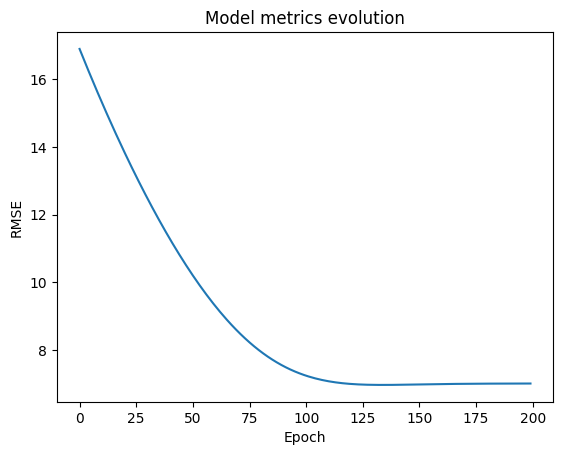

In [24]:
# Display evaluation metrics

print(f"RMSE: {best_rmse:.4f}")
plt.plot(history)
plt.title("Model metrics evolution")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.show()

RMSE: 6.6347


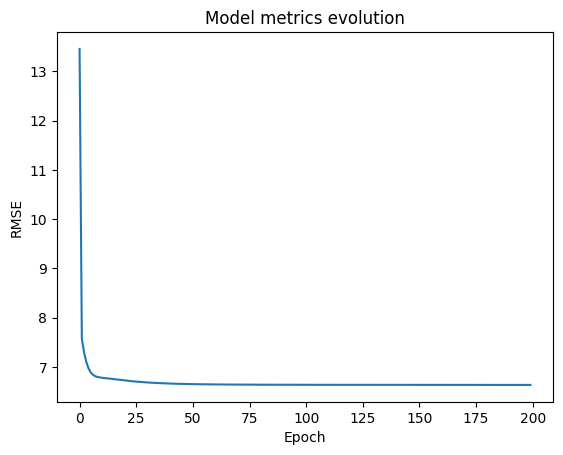

In [25]:
# Without GDP in the inputs

# Pyramid structure with 5 inputs and two hidden layers
model = nn.Sequential(
    nn.Linear(5, 24),
    nn.ReLU(),
    nn.Linear(24, 12),
    nn.ReLU(),
    nn.Linear(12, 6),
    nn.ReLU(),
    nn.Linear(6, 1)
)

# Optimizer: ADAM
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Variables to hold the best model
best_rmse = np.inf
best_weights = None
history = []

n_epochs = 200

for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:

            # Pick data batch
            X_batch = new_X_train_nn[start:start + batch_size]
            y_batch = y_train_nn[start:start + batch_size]

            # Forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()

            # Update weights
            optimizer.step()

            # Print progress
            bar.set_postfix(mse=float(loss))

    # Measure RMSE at the end of each epoch on the test set
    model.eval()
    y_pred = model(new_X_test_nn)
    mse = loss_fn(y_pred, y_test_nn)
    rmse = float(mse) ** 0.5
    history.append(rmse)

    # In case of improvement, save model weights
    if rmse < best_rmse:
        best_rmse = rmse
        best_weights = copy.deepcopy(model.state_dict())

# Restore best model weights found
model.load_state_dict(best_weights)

print(f"RMSE: {best_rmse:.4f}")
plt.plot(history)
plt.title("Model metrics evolution")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.show()

In [26]:
# Save model

torch.save(model.state_dict(), "models/best_nn_weights.pkl")

### Create a LIME Explainer for the Neural Network

In [27]:
explainer = LimeTabularExplainer(
    training_data=new_X_train_scaled,
    feature_names=feature_names,
    mode="regression",
)

True wage gap:   9.344642639160156
Predicted value: 17.824026107788086
[('immigrant_gap', 0.31552626182271337), ('employment_gap', 0.20856826407781964), ('part_time_gap', 0.15519421418789697), ('education_gap', 0.3652532497828407), ('native_gap', 0.7660596144269758)]
[('part_time_gap <= 0.16', 4.145355841865828), ('immigrant_gap <= 0.35', -2.949666602399928), ('native_gap > 0.69', 2.0334144366903435), ('0.21 < employment_gap <= 0.29', -0.6721965851245858), ('0.34 < education_gap <= 0.42', -0.2934931051709352)]


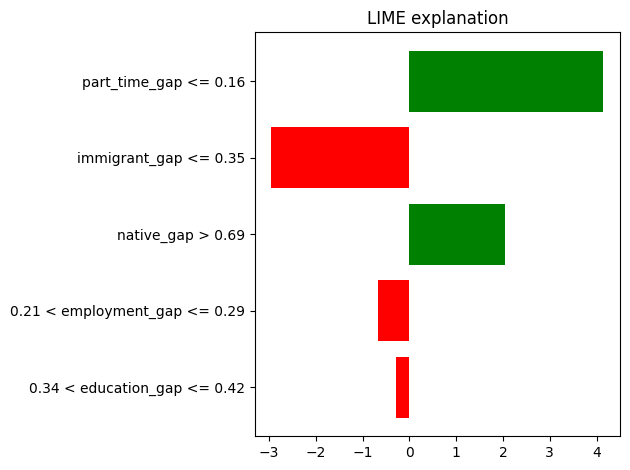

True wage gap:   11.786128044128418
Predicted value: 12.585916519165039
[('immigrant_gap', 0.7021537325379724), ('employment_gap', 0.9665237769272338), ('part_time_gap', 0.9564758500079414), ('education_gap', 0.8228635409379657), ('native_gap', 0.9128548054350143)]
[('part_time_gap > 0.35', -6.664365076402187), ('immigrant_gap > 0.59', 3.30215552716365), ('employment_gap > 0.41', 2.3564125028809118), ('native_gap > 0.69', 1.967494711664795), ('education_gap > 0.42', 0.006219806691332499)]


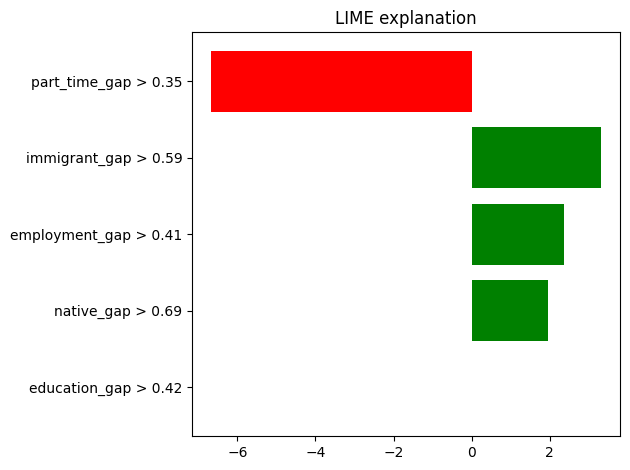

True wage gap:   17.083343505859375
Predicted value: 15.788930892944336
[('immigrant_gap', 0.6541313427166511), ('employment_gap', 0.6497960991382111), ('part_time_gap', 0.5615252529596229), ('education_gap', 0.7097157392562408), ('native_gap', 0.6417443266699864)]
[('part_time_gap > 0.35', -6.509658556481383), ('immigrant_gap > 0.59', 3.1385895280056335), ('employment_gap > 0.41', 2.351743607075638), ('0.54 < native_gap <= 0.69', 0.5811274835506985), ('education_gap > 0.42', -0.0985547927690464)]


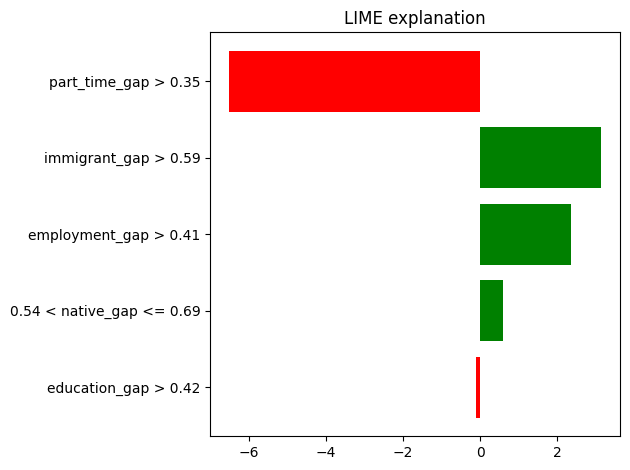

In [28]:
# Visualize some test data points

model.eval()

for i in [10, 20, 30]:

    inputs = new_X_test_scaled[i]
    nn_inputs = new_X_test_nn[i]
    true_target = y_test_nn[i][0]
    pred_target = model(nn_inputs)[0]

    print(
        f"True wage gap:   {true_target}",
        f"Predicted value: {pred_target}",
        sep="\n",
    )

    def wrapped_predict(data):
        return model(torch.tensor(data, dtype=torch.float32)).detach().numpy()

    exp = explainer.explain_instance(
        inputs,
        wrapped_predict,
        num_features=len(feature_names),
    )

    print([(f, float(x)) for f, x in zip(feature_names, inputs)])
    print(exp.as_list())

    fig = exp.as_pyplot_figure(label=true_target)
    plt.title("LIME explanation")
    plt.tight_layout()
    plt.show()